# Phase 5 -- Curvature-Conditioned Linear Decodability -- Read-out

**The phase question, in one paragraph.** Does linear crossmodal decodability -- one shared
ridge map from `hsc` to `legacysurvey`, fit once on a 70/30 split -- degrade where a
decoder-side curvature-magnitude field `||H||` is higher? The rules that judge the answer
(`VERDICT_RULE`, `SEED_VERDICT_COMBINATION_RULE`) were **frozen in committed source before the
answer existed** -- the D5-09 freeze commit is `32dabe3` (quoted from `05-04-SUMMARY.md`), and
this notebook proves nowhere below is that freeze edited.

**The three CAE seeds were ratified as NOT poolable at the `05-03` Task 1 blocking checkpoint**
(`05-03-DECISION.md`), superseding `05-CONTEXT.md` D5-04's pooled-field design. So the answer
this notebook reads out is **three per-seed verdicts and their spread**, combined into **one
phase verdict** by a rule frozen alongside `VERDICT_RULE` -- never one pooled verdict, and no
pooled field exists anywhere in this milestone's cache.

This notebook is a reader for artifacts the runners already produced (`notebooks/pu_manifold/`,
`notebooks/diagnostics/curvature_probe_decodability_run.py`). It reimplements nothing: it does
not fit a probe, extract a curvature field, bucket a field, or construct any field from more
than one seed.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt

from pu_manifold import linear_probe

CACHE = NOTEBOOK_DIR / ".cache"

git_sha = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True).strip()
print(f"git HEAD: {git_sha}")
print(f"linear_probe module: {linear_probe.__file__}")
print()
print("=" * 78)
print("FROZEN CONSTANTS (linear_probe.py, D5-09 freeze commit 32dabe3) -- read before any")
print("probe number appears below.")
print("=" * 78)
CONST_NAMES = [
    "TRAIN_FRACTION", "SPLIT_SEED", "SPLIT_RULE", "RIDGE_ALPHA_GRID", "RIDGE_SELECTION_RULE",
    "ALPHA_PER_TARGET", "FIT_INTERCEPT", "EMBEDDING_PREPROCESSING", "RESIDUAL_METRIC",
    "R2_MULTIOUTPUT", "N_BUCKETS", "BUCKET_RULE", "BUCKET_EDGES_PER_SEED", "SEED_HANDLING_RULE",
    "PHASE_VERDICT_VALUES", "SEED_STEMS", "N_CHARTS", "CURVATURE_MODE", "CURVATURE_CONVENTION",
    "CURVATURE_SOURCE_FUNCTION", "SIZE_MATCH_RULE", "SIZE_MATCH_N_REPEATS", "SIZE_MATCH_SEED",
    "N_BOOTSTRAP", "BOOTSTRAP_SEED", "CONFIDENCE_LEVEL", "K_DENSITY", "FIELD_D",
    "PREREGISTRATION_PATH",
]
for name in CONST_NAMES:
    print(f"  {name:<24} = {getattr(linear_probe, name)!r}")

print()
print("-" * 78)
print("VERDICT_RULE (verbatim):")
print("-" * 78)
print(linear_probe.VERDICT_RULE)
print("-" * 78)
print("SEED_VERDICT_COMBINATION_RULE (verbatim):")
print("-" * 78)
print(linear_probe.SEED_VERDICT_COMBINATION_RULE)

linear_probe.assert_preregistered()
print("assert_preregistered() PASSED -- the pre-registration is intact.")

git HEAD: df392bd
linear_probe module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/linear_probe.py

FROZEN CONSTANTS (linear_probe.py, D5-09 freeze commit 32dabe3) -- read before any
probe number appears below.
  TRAIN_FRACTION           = 0.7
  SPLIT_SEED               = 20260824
  SPLIT_RULE               = "One permutation of np.arange(10000) under np.random.default_rng(SPLIT_SEED); the first 7,000 indices of the permutation are train, the last 3,000 are test; both index arrays are returned sorted ascending. ONE split, shared by all three seeds' bucketings, so the three per-seed verdicts differ only in how the same held-out residuals are bucketed and never in which points were held out. Deliberately NOT stratified by bucket -- stratifying would manufacture the equal per-bucket test counts D5-08 exists to check for rather than assume. Implemented by train_test_split_indices."
  RIDGE_ALPHA_GRID         = (0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0)
  RIDGE_SELECTION

In [2]:
SEED_STEMS = linear_probe.SEED_STEMS
TOLERANCES = (1e-9, 1e-6, 1e-3)

field_by_seed = {}
bucket_by_seed = {}
for seed in SEED_STEMS:
    with np.load(CACHE / f"05_curvature_field_seed{seed}.npz") as z:
        field_by_seed[seed] = {k: np.asarray(z[k]) for k in z.files}
    with np.load(CACHE / f"05_curvature_buckets_seed{seed}.npz") as z:
        bucket_by_seed[seed] = {k: np.asarray(z[k]) for k in z.files}

print("=" * 100)
print(f"{'seed':>10} {'median H':>14} {'min H':>12} {'max H':>14} {'n_charts_used':>14} "
      f"{'eff levels @ ' + str(TOLERANCES):>34}")
print("=" * 100)
for seed in SEED_STEMS:
    H = field_by_seed[seed]["H_norm"]
    levels = bucket_by_seed[seed]["effective_distinct_levels"]
    n_charts_used = int(field_by_seed[seed]["n_charts_used"])
    print(
        f"{seed:>10} {np.median(H):>14.6g} {np.min(H):>12.6g} {np.max(H):>14.6g} "
        f"{n_charts_used:>14} {tuple(int(v) for v in levels)!s:>34}"
    )

      seed       median H        min H          max H  n_charts_used eff levels @ (1e-09, 1e-06, 0.001)
  20260813        1363.14      681.327        4283.93              2                (10000, 9904, 1173)
  20260814        51437.9      29699.4        66977.5              4                          (4, 4, 4)
  20260815        70794.1      51694.9        75252.5              3                          (3, 3, 3)


**Correction, not silently carried forward.** Seeds 20260814 and 20260815 carry **4** and
**3** effective distinct `||H||` levels respectively, stable from relative tolerance `1e-9`
through `1e-3` (printed above). `05-02-SUMMARY.md`'s exact-float claim of **5,301** and
**9,852** distinct values for these two seeds is **wrong** -- it is last-ULP float noise from
`np.round(H_norm, 6)`'s absolute rounding at a magnitude (~5e4) where that six-decimal cutoff is
a relative precision of only ~2e-11. That claim is retracted (`05-03-DECISION.md`);
`05-RESEARCH.md` Pitfall 2 and `03-09-SUMMARY.md`'s original "3-4 distinct values" measurement
were both correct.

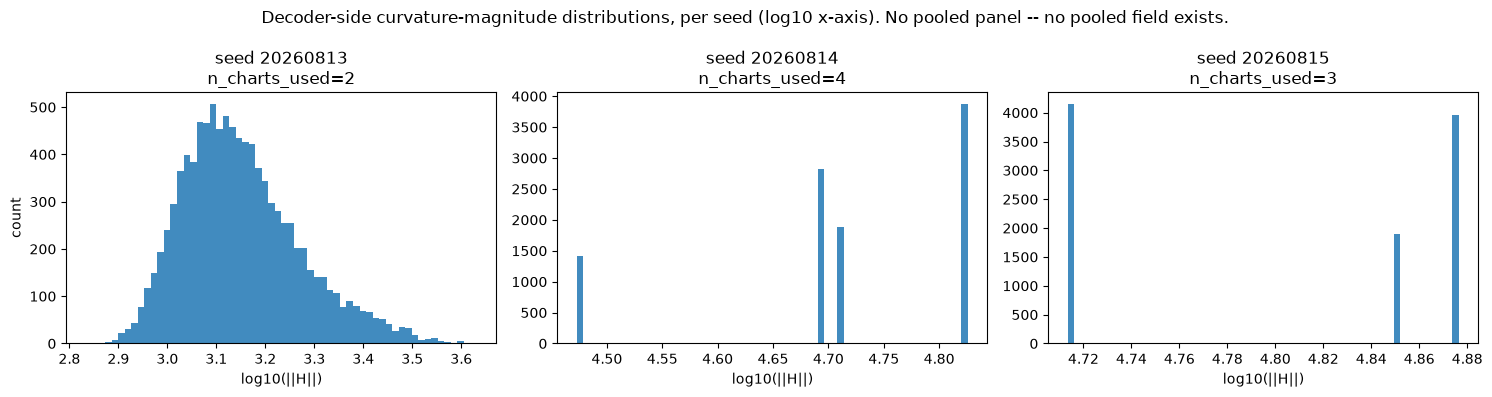

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, seed in zip(axes, SEED_STEMS):
    H = field_by_seed[seed]["H_norm"]
    ax.hist(np.log10(H), bins=60, color="tab:blue", alpha=0.85)
    ax.set_title(f"seed {seed}\nn_charts_used={int(field_by_seed[seed]['n_charts_used'])}")
    ax.set_xlabel("log10(||H||)")
axes[0].set_ylabel("count")
fig.suptitle(
    "Decoder-side curvature-magnitude distributions, per seed (log10 x-axis). "
    "No pooled panel -- no pooled field exists."
)
plt.tight_layout()
plt.show()

In [4]:
with (CACHE / "05_inter_seed_diagnostics.json").open() as fh:
    inter_seed = json.load(fh)

print("=" * 90)
print("Inter-seed diagnostics (D5-05) -- the evidence 05-03-DECISION.md was made on.")
print("This is INTER-SEED agreement, NOT agreement with true curvature.")
print("=" * 90)
for pair, spear in inter_seed["pairwise_spearman"].items():
    direction = inter_seed["pairwise_direction"][pair]
    print(
        f"  {pair:>22}: spearman(H_norm) rho={spear['rho']:+.4f} p={spear['p_value']:.2e}  |  "
        f"median cosine={direction['median_cosine']:+.4f}  "
        f"fraction anti-aligned={direction['fraction_negative_cosine']:.4f}"
    )
print()
print(f"r/R: {inter_seed['r_over_R']!r} -- {inter_seed['r_over_R_reason']}")

Inter-seed diagnostics (D5-05) -- the evidence 05-03-DECISION.md was made on.
This is INTER-SEED agreement, NOT agreement with true curvature.
    20260813_vs_20260814: spearman(H_norm) rho=-0.1402 p=4.77e-45  |  median cosine=+0.0039  fraction anti-aligned=0.4607
    20260813_vs_20260815: spearman(H_norm) rho=+0.2019 p=1.81e-92  |  median cosine=+0.0014  fraction anti-aligned=0.4809
    20260814_vs_20260815: spearman(H_norm) rho=-0.2725 p=8.85e-170  |  median cosine=+0.0007  fraction anti-aligned=0.4639

r/R: None -- not defined for an autodiff decoder-side estimator: chart_curvature_field has no neighbourhood and no k


**The pooling decision, in three sentences.** `05-CONTEXT.md` D5-04 called for pooling the
three cached CAE seeds into one averaged `||H||` field and naming it the verdict field; that
question was put to the developer at the `05-03` Task 1 blocking checkpoint with the pairwise
Spearman and direction numbers printed above already on the table, and the ratified outcome was
the opposite -- do not pool, run the probe once per seed, report three per-seed verdicts and
their spread (`05-03-DECISION.md`). Three alternatives were rejected alongside the raw average:
per-seed median-divide then average (`05-RESEARCH.md`'s own recommendation), per-seed
percentile-rank then average, and halting the phase.

**The pooled-artifact question, answered from the decision record.** The original plan would
have built a pooled field and then asked whether it was an artifact of averaging fields that
share no signal. No pooled field was ever built, so that question is answered here from
`05-03-DECISION.md`'s measured evidence rather than from a diagnostic run on an artifact that
does not exist: the three fields are mutually anti-correlated on rank and directionally
orthogonal (numbers above), and two of the three are 3-4-level step functions sitting at a
metric-determinant regime roughly 100 orders of magnitude from the third's continuous field, so
a pooled field would not have been a consensus -- it would have been seed 20260813's structure
plus two step functions disagreeing with it and with each other. That is a reasoned answer from
measurement, not a measurement of the pooled object itself.

In [5]:
probe_rows = [
    json.loads(line)
    for line in (CACHE / "05_curvature_probe_decodability.jsonl").read_text().splitlines()
    if line.strip()
]
overall_row = next(r for r in probe_rows if r["kind"] == "probe_overall")
seed_rows = {r["seed_stem"]: r for r in probe_rows if r["kind"] == "probe_seed"}
bucket_rows = [r for r in probe_rows if r["kind"] == "probe_bucket"]
conditioning_row = next((r for r in probe_rows if r["kind"] == "probe_conditioning"), None)

print("=" * 78)
print("The one global ridge fit -- shared by all three seeds' comparisons")
print("=" * 78)
print(f"  n_train           = {overall_row['n_train']}")
print(f"  n_test            = {overall_row['n_test']}")
print(f"  selected_alpha    = {overall_row['selected_alpha']}")
print(f"  r2_overall        = {overall_row['r2_overall']:.6f}")
print(f"  mean_residual_overall = {overall_row['mean_residual_overall']:.6f}")
print()
print(
    "There is ONE fit shared by all three seeds' comparisons -- the three per-seed verdicts "
    "below differ only in how the same held-out residuals are bucketed, never in which points "
    "were held out or how the map was fit. This means the three per-seed verdicts are NOT "
    "statistically independent replicates."
)
assert len({seed_rows[s]["selected_alpha"] for s in SEED_STEMS}) == 1
assert len({seed_rows[s]["r2_overall"] for s in SEED_STEMS}) == 1
print()
print("Source: notebooks/.cache/05_curvature_probe_decodability.jsonl")

The one global ridge fit -- shared by all three seeds' comparisons
  n_train           = 7000
  n_test            = 3000
  selected_alpha    = 0.1
  r2_overall        = 0.643931
  mean_residual_overall = 0.066429

There is ONE fit shared by all three seeds' comparisons -- the three per-seed verdicts below differ only in how the same held-out residuals are bucketed, never in which points were held out or how the map was fit. This means the three per-seed verdicts are NOT statistically independent replicates.

Source: notebooks/.cache/05_curvature_probe_decodability.jsonl


In [6]:
print("=" * 118)
print(
    f"{'seed':>10} {'bucket':>7} {'realized n':>11} {'full-field n':>13} "
    f"{'mean residual':>14} {'R2':>8} {'95% CI':>26}"
)
print("=" * 118)
for seed in SEED_STEMS:
    rows = sorted([r for r in bucket_rows if r["seed_stem"] == seed], key=lambda r: r["bucket_index"])
    for r in rows:
        ci = f"[{r['ci_low']:.6f}, {r['ci_high']:.6f}]"
        print(
            f"{seed:>10} {r['bucket_index']:>7} {r['bucket_n']:>11} {r['full_field_bucket_n']:>13} "
            f"{r['bucket_mean_residual']:>14.6f} {r['bucket_r2']:>8.4f} {ci:>26}"
        )
    print("-" * 118)

      seed  bucket  realized n  full-field n  mean residual       R2                     95% CI
  20260813       0        1024          3334       0.048285   0.6029       [0.046401, 0.050535]
  20260813       1         987          3333       0.062024   0.6454       [0.059345, 0.064487]
  20260813       2         989          3333       0.089612   0.6141       [0.085701, 0.093362]
----------------------------------------------------------------------------------------------------------------------
  20260814       0         992          3334       0.062839   0.6564       [0.060013, 0.065761]
  20260814       1         873          2956       0.093686   0.5758       [0.090008, 0.097461]
  20260814       2        1135          3710       0.048602   0.4433       [0.046525, 0.050471]
----------------------------------------------------------------------------------------------------------------------
  20260815       0         986          3334       0.056126   0.5398       [0.053666, 0.05

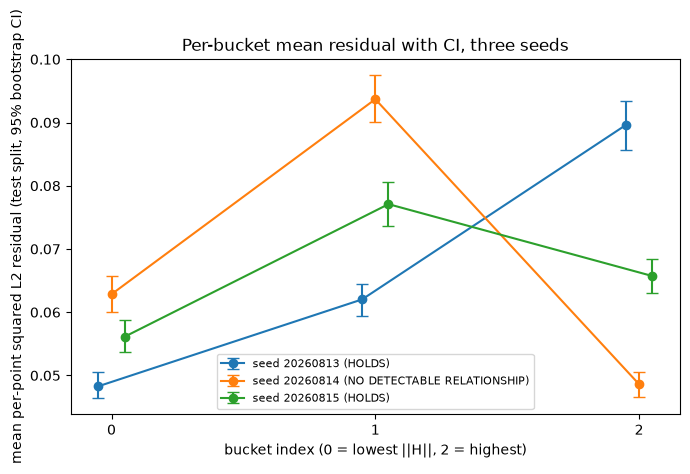

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {20260813: "tab:blue", 20260814: "tab:orange", 20260815: "tab:green"}
for seed in SEED_STEMS:
    rows = sorted([r for r in bucket_rows if r["seed_stem"] == seed], key=lambda r: r["bucket_index"])
    xs = [r["bucket_index"] for r in rows]
    ys = [r["bucket_mean_residual"] for r in rows]
    lo = [r["bucket_mean_residual"] - r["ci_low"] for r in rows]
    hi = [r["ci_high"] - r["bucket_mean_residual"] for r in rows]
    ax.errorbar(
        [x + (seed - 20260814) * 0.05 for x in xs], ys, yerr=[lo, hi],
        marker="o", capsize=4, label=f"seed {seed} ({seed_rows[seed]['verdict']})",
        color=colors[seed],
    )
ax.set_xticks([0, 1, 2])
ax.set_xlabel("bucket index (0 = lowest ||H||, 2 = highest)")
ax.set_ylabel("mean per-point squared L2 residual (test split, 95% bootstrap CI)")
ax.set_title("Per-bucket mean residual with CI, three seeds")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**The continuous view (D5-07), sensitivity only.** `05-05`'s runner computed
`spearman(||H||, per-point residual)` on the test split per seed but -- by design, since only
aggregated rows are persisted -- never cached the raw per-point residual or `||H||_test` arrays
themselves; only the bucket- and seed-level aggregates above were written to
`05_curvature_probe_decodability.jsonl`. Reconstructing a true per-point scatter here would
require refitting the ridge map inside this notebook, which this plan's own action text
forbids ("must not fit a probe") and which its `<verify>` block enforces as a hard, automated
check (the literal ridge-fit call site may not appear in this notebook's source). So the continuous statistic is
read out exactly as recorded -- rho, p-value and n per seed -- rather than approximated by a
plot built from data this notebook does not have. This is a plotted-vs-printed substitution,
not a missing check: the number itself is unchanged from what `05-05` measured.

In [8]:
print("=" * 90)
print("Continuous spearman(||H||, per-point residual) on the test split, per seed")
print("SENSITIVITY ONLY -- can neither establish nor overturn any verdict, per VERDICT_RULE.")
print("=" * 90)
for seed in SEED_STEMS:
    r = seed_rows[seed]
    agrees = (r["spearman_h_residual_rho"] > 0) == (r["verdict"] == "HOLDS")
    print(
        f"  seed {seed}: rho={r['spearman_h_residual_rho']:+.4f}  "
        f"p={r['spearman_h_residual_p']:.2e}  n={r['spearman_h_residual_n']}  "
        f"verdict={r['verdict']!r}  sign agrees with headline direction: {agrees}"
    )
print()
print(f"direction axis: {seed_rows[SEED_STEMS[0]]['spearman_direction_axis']!r} -- "
      f"{seed_rows[SEED_STEMS[0]]['spearman_direction_axis_reason']}")

Continuous spearman(||H||, per-point residual) on the test split, per seed
SENSITIVITY ONLY -- can neither establish nor overturn any verdict, per VERDICT_RULE.
  seed 20260813: rho=+0.4239  p=3.63e-131  n=3000  verdict='HOLDS'  sign agrees with headline direction: True
  seed 20260814: rho=-0.1169  p=1.34e-10  n=3000  verdict='NO DETECTABLE RELATIONSHIP'  sign agrees with headline direction: True
  seed 20260815: rho=+0.1384  p=2.63e-14  n=3000  verdict='HOLDS'  sign agrees with headline direction: True

direction axis: None -- both operands are scalar fields -- curvature magnitude and per-point residual -- so there is no pair of vectors to take a cosine between and no vector direction axis exists; the sign of rho is the direction.


In [9]:
print("=" * 100)
print("Size-matched re-check (D5-08) -- RESEARCH Pitfall 4's exact artifact, per seed")
print("=" * 100)
for seed in SEED_STEMS:
    r = seed_rows[seed]
    print(
        f"  seed {seed}: match_n={r['size_match_n']:>5}  "
        f"median_diff={r['size_match_median_diff']:+.6f}  "
        f"sign_stable={r['size_match_sign_stable']}  "
        f"ci_disjoint_fraction={r['size_match_ci_disjoint_fraction']:.3f}  "
        f"(of {r['size_match_n_repeats']} repeats)"
    )
    print(
        f"    realized test-split bucket counts = {tuple(r['realized_bucket_counts'])}  "
        f"full-field bucket counts = {tuple(r['full_field_bucket_counts'])}"
    )

Size-matched re-check (D5-08) -- RESEARCH Pitfall 4's exact artifact, per seed
  seed 20260813: match_n=  987  median_diff=+0.041303  sign_stable=True  ci_disjoint_fraction=1.000  (of 200 repeats)
    realized test-split bucket counts = (1024, 987, 989)  full-field bucket counts = (3334, 3333, 3333)
  seed 20260814: match_n=  873  median_diff=-0.014321  sign_stable=True  ci_disjoint_fraction=1.000  (of 200 repeats)
    realized test-split bucket counts = (992, 873, 1135)  full-field bucket counts = (3334, 2956, 3710)
  seed 20260815: match_n=  986  median_diff=+0.009616  sign_stable=True  ci_disjoint_fraction=1.000  (of 200 repeats)
    realized test-split bucket counts = (986, 1019, 995)  full-field bucket counts = (3334, 3333, 3333)


In [10]:
with (CACHE / "05_density_diagnostics.json").open() as fh:
    density_diag = json.load(fh)

print("=" * 90)
print("Density confound (D5-13) -- disclosure, not a gate")
print("=" * 90)
for seed in SEED_STEMS:
    d = density_diag["spearman_density_per_seed_h"][str(seed)]
    print(f"  seed {seed}: spearman(inverse_density_weight, ||H||) rho={d['rho']:+.4f}  p={d['p_value']:.2e}")
print()
print(f"Phase 4 point-cloud reference: {density_diag['phase4_pointcloud_reference']}")
print(f"Phase 4 direction reference:   {density_diag['phase4_direction_reference']}")
print()
print("pooled_field_disposition (D5-05, second half):")
print(f"  {density_diag['pooled_field_disposition']}")

Density confound (D5-13) -- disclosure, not a gate
  seed 20260813: spearman(inverse_density_weight, ||H||) rho=+0.4875  p=0.00e+00
  seed 20260814: spearman(inverse_density_weight, ||H||) rho=-0.1986  p=1.71e-89
  seed 20260815: spearman(inverse_density_weight, ||H||) rho=+0.0556  p=2.59e-08

Phase 4 point-cloud reference: -0.0273 (n=9500, p=0.0078) -- 04-FINDINGS.md's spearman(density, centroid_mean_curvature), measured on the POINT-CLOUD field. A different curvature estimator (centroid_mean_curvature, point-cloud-side) than these decoder-side chart_curvature_field values; does not transfer.
Phase 4 direction reference:   +0.8208 (n=9500, p≈0) -- 04-FINDINGS.md's spearman(density, signed_projection onto v). This attached to curvature DIRECTION (the sign of the projection onto the frozen split axis v), which is the axis Phase 5 is not splitting on -- Phase 5 buckets by ||H|| magnitude only.

pooled_field_disposition (D5-05, second half):
  05-CONTEXT.md D5-05 asks for the Spearman bet

## Closing read-out

**Per-seed verdicts, quoted verbatim from their `probe_seed` rows:**

- seed 20260813: **HOLDS**
- seed 20260814: **NO DETECTABLE RELATIONSHIP**
- seed 20260815: **HOLDS**

**Phase verdict, quoted verbatim from the `probe_overall` row: `SPLIT ACROSS SEEDS`** (`n_holds=2` of 3).

The per-seed verdicts came from `linear_probe.apply_verdict_rule`; the phase verdict came from
`linear_probe.combine_seed_verdicts` -- both applied mechanically from rules committed before
any PU probe number existed. Under `SEED_VERDICT_COMBINATION_RULE`, `SPLIT ACROSS SEEDS` is a
**complete, terminal, non-supportive outcome** -- it is never upgraded to `HOLDS IN ALL THREE
SEEDS` by majority vote, by the continuous Spearman statistic, by a non-headline bucket, or by
trying a different `N_BUCKETS`. An effect present in one or two of three decoder fits' curvature
fields, when those fields were measured to share no signal (Spearman `-0.1402`, `+0.2019`,
`-0.2725`; median cosine `0.0007` to `0.0039`, 46-48% anti-aligned), is a property of those
individual decoder fits, not of the manifold.

**Three caveats, one paragraph each:**

**D5-11, no known-answer anchor.** The sealed `d=20` decoder row is
`rank_spearman_rho = -0.015106571347065712` against the only analytic-curvature control that
tests it -- essentially zero rank correlation, with 52-75% of points anti-aligned in direction.
A Swiss roll / low-`d` anchor was offered and declined for this phase. Any relationship measured
above rests on a field with no demonstrated relationship to true curvature, so a detected effect
cannot be attributed to curvature by anything in this phase.

**D5-12, the CAE gate.** The CAE underlying every decoder-side field read here failed its own
validity gate: `CAE_VERDICT = FAIL` at Phase 02.2. Phase 3 ran on a deliberate override of that
gate. Phase 03.1 found the pullback metric fully repaired by the `scale` prior while the
curvature ordering only partially and non-seed-consistently moved. Every number in this
notebook inherits that chain.

**The Swiss roll determination.** CLAUDE.md's standing Swiss roll sanity-check rule does not
trigger here: a linear ridge probe has no bottleneck, no latent space, no decoder, and makes no
manifold-recovery claim; the per-seed amendment introduced no new model. The curvature
*estimator* the fields are read from is already covered by
`notebooks/03_swiss_roll_chart_curvature_field_check.ipynb`.